# Evaluation of regularized balancing estimators

This notebook implements the paper's evaluation study in Section 6 and Appendix E. It is a self-contained comparison, separate from Numerical Experiments I--IV. The design is fixed before simulation, uses an honest pilot/evaluation split of the target sample, and retains every Monte Carlo replication.

The central question is whether the proposed target-aware ridge augmentation improves counterfactual prediction while controlling the accompanying variance and weight instability. Eight outcome-free base weighting procedures are compared with the same centered affine ridge update; the last two are the weighting components of the two complete two-stage comparators -- the $\ell_2$ balancing component of double-ridge ABW at its design-only Riesz-CV penalty, and the residual-balancing component of ARB. Full double-ridge ABW and full ARB are evaluated as complete two-stage estimators on the rows of their own weighting components. Sample-trimmed IPW is stored as a distinct retained-population sensitivity analysis. All plotted uncertainty bars are Monte Carlo uncertainty summaries, not confidence intervals for a single fitted dataset.


## How to use this notebook

This notebook **reads results and plots**.  It runs no experiment, so it
executes in seconds.

The sweep lives in `experiments/evaluation/` and is run separately:

```
python -m experiments.evaluation.run
CAUSAL_EXTRAPOLATION_SMOKE=1 python -m experiments.evaluation.run --smoke
```

That writes `results/evaluation/`, which is what the cells below read.  The
estimator, the competing weight families and the risk formulas come from the
`rcb` package; this study's data-generating process and numerical policy are in
`experiments/evaluation/dgp.py`.


## Evaluation roadmap

| Block | Statistical question | Main output |
|---|---|---|
| Design and estimands | Are the DGP, overlap regimes, target split, and exact risk definitions aligned with the paper? | Configuration and assumption audit |
| Estimator comparison | Does target-aware augmentation improve counterfactual prediction for each base weighting family? | Evaluation Figure 1: empirical RMSE |
| Mechanism decomposition | Is any improvement driven by lower bias without an excessive variance or weight-norm cost? | Evaluation Figure 2: five exact-risk and geometry metrics |
| Tuning comparison | Does the feasible spectral target-aware rule track the infeasible risk-optimal penalty? | Evaluation Figure 3: selected penalty and excess exact risk |
| Reproducibility | Are all replications complete, finite, normalized, and algebraically consistent? | Validation tables and saved draw-level files |

The two source aspect ratios are reported separately: $\phi_0=p/n_0=0.5$ is underparameterized ($n_0=100$), while $\phi_0=1.25$ is overparameterized ($n_0=40$). Within each figure, columns or rows labeled by overlap always use the same three population shift magnitudes.


## I. Experimental design

### 1. Paper-aligned configuration

The following cell fixes the dimension, source and target sample sizes, target split, signal and noise levels, overlap regimes, penalty grid, Monte Carlo replication count, method order, and plotting conventions. These values are subsequently written to `configuration.csv` so that the figures can be audited without reopening the notebook.


In [1]:
import sys
from pathlib import Path

CODE = Path.cwd()
if str(CODE) not in sys.path:
    sys.path.insert(0, str(CODE))

import json
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import seaborn as sns

from rcb import paths
from experiments.evaluation.dgp import (
    FAMILY_LABELS, FAMILY_ORDER, FAMILY_SHORT_LABELS, HEADLINE_STAGES, N1,
    OVERLAP_SETTINGS, P, PHI0_SETTINGS, PHI1, PILOT_FRACTION, R2, RHO_AR,
    SIGMA02, SIGMA0_EIGENVALUES, TAU,
)
from rcb.style import COLORS as PALETTE

STUDY = "evaluation"
RESULTS = paths.results(STUDY, create=False)
FIGURE_DIR = paths.figures(STUDY)
ARTIFACT_DIR = RESULTS
PART2_DIR = FIGURE_DIR

sns.set_theme(style="whitegrid", context="notebook", font="DejaVu Sans", font_scale=1.55)

print(pd.read_csv(RESULTS / "configuration.csv").T.to_string())

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                0
seed                                                                                                                                                                                                                                                                                                                                                                                                                                  

### 2. Data-generating process and assumption audit

This section shares Section 5's Gaussian AR(1) source-target family: $(\Sigma_0)_{jk}=\rho_{\mathrm{AR}}^{|j-k|}$ with $\rho_{\mathrm{AR}}=0.5$ and $\Sigma_1=\Sigma_0$. The paper fixes $p=50$, $n_1=100$, $n_0\in\{100,40\}$, and
\[
X_{0i}=\Sigma_0^{1/2}Z_{0i},\qquad X_{1i}=\nu_\delta+\Sigma_0^{1/2}Z_{1i},\qquad
Z_{ai}\stackrel{\mathrm{iid}}{\sim}N(0,I_p),
\]
with $\delta\in\{0.5,1,\sqrt3\}$. The shift $\nu_\delta$ is diffuse in $\Sigma_0$'s eigenbasis and Mahalanobis-normalized so that $\nu_\delta^\top\Sigma_0^{-1}\nu_\delta=\delta^2$ exactly (`rcb.dgp.mahalanobis_rescale`), so the exact density ratio remains $w(x;\delta)=\exp\{\nu_\delta^\top\Sigma_0^{-1}x-\delta^2/2\}$ and the population effective-sample-size fractions are unchanged from the isotropic design, $\exp(-\delta^2)\in\{0.779,0.368,0.050\}$, labeled strong, intermediate weak, and severe weak overlap.

For each replication,
\[
\beta=p^{-1/2}\xi,\qquad \xi\sim N(0,I_p),\qquad
Y(0)=X^\top\beta+\epsilon,\qquad \epsilon\sim N(0,0.5),
\]
i.e. $r^2=1$, matching Section 5's common outcome model, and the treatment effect is $\tau=1$. The 100 target observations are randomly divided into 50 pilot and 50 evaluation observations. The pilot fold constructs the base weights; the disjoint evaluation fold enters the target-aware criterion and held-out imbalance diagnostic. They are not treated as two independent target samples of size 100.

In [2]:
assumption_audit = pd.DataFrame({
    "condition": [
        "Assumption 3: P1 << P0", "Assumption 4: linear m0(x)",
        "Assumption 5/8: isotropic independent beta", "Assumption 6(i): standardized independent Gaussian arrays",
        "Assumption 6(i): bounded covariance spectrum", "Algorithms 1-2: honest target split",
        "Propensity baseline specification",
    ],
    "status": ["exact", "exact", "exact", "exact", "exact", "exact", "exact"],
    "implementation": [
        "Both arm laws are nonsingular Gaussian on R^p with common covariance Sigma0",
        "Y(0)=X'beta+epsilon0 with zero intercept",
        "beta=sqrt(r2/p) xi, xi_j iid N(0,1), redrawn each replication",
        "X0=Sigma0^{1/2}Z0, X1=nu_delta+Sigma0^{1/2}Z1 with iid standard Gaussian Z",
        f"eigenvalues in [{SIGMA0_EIGENVALUES.min():.3f}, {SIGMA0_EIGENVALUES.max():.3f}]",
        "Base uses pilot fold; Delta and OOD risk use disjoint evaluation fold",
        "Gaussian equal-covariance density ratio is exactly log-linear",
    ],
})
print(assumption_audit.to_string())

                                                   condition status                                                               implementation
0                                     Assumption 3: P1 << P0  exact  Both arm laws are nonsingular Gaussian on R^p with common covariance Sigma0
1                                 Assumption 4: linear m0(x)  exact                                     Y(0)=X'beta+epsilon0 with zero intercept
2                 Assumption 5/8: isotropic independent beta  exact                beta=sqrt(r2/p) xi, xi_j iid N(0,1), redrawn each replication
3  Assumption 6(i): standardized independent Gaussian arrays  exact   X0=Sigma0^{1/2}Z0, X1=nu_delta+Sigma0^{1/2}Z1 with iid standard Gaussian Z
4               Assumption 6(i): bounded covariance spectrum  exact                                                eigenvalues in [0.334, 2.979]
5                        Algorithms 1-2: honest target split  exact        Base uses pilot fold; Delta and OOD risk use disjoint e

### 3. Estimators and honest tuning

All base weights use only $(X_0,X_{1P})$. The held-out fold $X_{1E}$ is used only for the centered imbalance and the target-aware risk criterion. Every augmented weight vector remains affine normalized.

| Method family | Role in the comparison |
|---|---|
| Uniform | Unweighted source benchmark |
| IPW | Regularized logistic source odds |
| Stabilized entropy balancing, SBW, and CBPS | Outcome-free balancing baselines; SBW uses explicit sampling-error-scaled balance constraints |
| Overlap source weights | Source-arm overlap-oriented base; its unaugmented row is excluded from the ATT ranking because target outcomes are not overlap-weighted |
| $\ell_2$ balancing | Balancing component of double-ridge ABW: ridge balancing weights from the pilot fold at the authors' design-only Riesz-CV penalty $\hat\delta_{\mathrm{Riesz}}$ |
| ARB weights | Residual-balancing component of ARB (the published capped quadratic program), the very vector Full ARB corrects |
| Full double-ridge ABW | Complete outcome-CV estimator with $\delta=\lambda$, shown on the $\ell_2$ row; imbalance-CV and Riesz-CV variants are diagnostic only |
| Full ARB | Complete two-stage estimator, shown on the ARB row: the ARB weights plus an elastic-net outcome model |
| Sample-trimmed IPW | Separate sensitivity analysis that removes source and target observations outside $[0.05,0.95]$ and targets the retained target sample |

For the eight outcome-free families, **Base** denotes the original weights and **Our method** denotes the same centered affine ridge augmentation tuned by the spectral target-aware rule. The double-ridge implied weights are this same path from $w(\delta)$ at $\lambda$, so the $\ell_2$ row compares penalty rules on one path (with the base at $\hat\delta_{\mathrm{Riesz}}$ for the gray and blue markers and at $\hat\lambda_{\mathrm{CV}}$ for the green one). The global spectral quasi-score solution on the fixed parameter box supplies the headline nuisance estimates. Equation (4.1)'s two-moment estimates, source GCV, and the infeasible oracle are retained only as tuning diagnostics. The complete Full ABW and Full ARB estimators themselves are not passed through the centered-ridge path; only their outcome-free weighting components are.


### 5. Numerical and design validation

The checks below verify the requested dimension and sample sizes, the honest 50/50 target split, presence of all eight outcome-free base families, a positive Riesz-CV penalty for every $\ell_2$ base, 120 complete replications per method cell, affine normalization, finite outputs, and the identity $R_n=B_n+V_n$. Separate validation checks cover full ABW, Full ARB (including that its weight vector is the ARB base row's), and matched sample trimming. They also record nuisance-calibration diagnostics without using them to remove or alter any replication.


In [3]:
summary = pd.read_csv(RESULTS / "method_summary.csv")
checks = json.loads((RESULTS / "validation.json").read_text())
print(pd.Series(checks, name="validation").to_string())
print(pd.read_csv(RESULTS / "arb_validation.csv").to_string())
print(pd.read_csv(RESULTS / "nuisance_estimation_summary.csv").round(4).to_string())
print(pd.read_csv(RESULTS / "paired_nuisance_tuning_summary.csv").round(4).to_string())


paper_dimension_p_50                                True
paper_total_target_n1_100                           True
paper_source_sizes_100_and_40                       True
honest_target_split_is_50_plus_50                   True
honest_splits_all_disjoint                          True
eight_required_base_families_present                True
l2_base_penalty_positive_and_finite                 True
l2_base_penalty_at_riesz_grid_cap_fraction      0.143056
complete_replications_per_method_cell               True
production_configuration_is_120_replications        True
no_nonfinite_method_outputs                         True
exact_risk_equals_B_plus_V                          True
all_augmented_weights_affine_normalized             True
maximum_augmented_weight_sum_error                   0.0
spectral_quasi_score_is_headline                    True
two_moment_rule_is_diagnostic_only                  True
oracle_used_for_evaluation_only                     True
mean_beta_shift_cos2           

## II. Evaluation results

### 6. Evaluation Figure 1 -- counterfactual prediction RMSE

This is the estimator-level comparison in the overparameterized source design. For each overlap regime and outcome-free weighting family, the gray square is the base estimator and the blue circle is our target-aware augmentation. On the $\ell_2$ row the green diamond reports the pre-specified full double-ridge ABW rule with outcome CV and $\delta=\lambda$; on the ARB row the orange triangle reports Full ARB. Each of those two rows therefore shows the weighting component alone, the same component with risk-calibrated augmentation, and the authors' own outcome-model correction. Horizontal bars are $\pm2$ Monte Carlo standard errors of RMSE, obtained by the delta method from the 120 independent squared prediction errors.

The displayed panels use $\phi_0=1.25$; lower RMSE is better. The two alternative ABW tuning rules remain in diagnostic result files and are not promoted after inspecting their realized performance.


In [4]:
# The three renderers, reading the summaries the sweep wrote.

STUDY = "evaluation"
ARTIFACT_DIR = paths.results(STUDY, create=False)
FIGURE_DIR = paths.figures(STUDY, create=False)
# The manuscript-facing aliases sit beside the figures they alias.
PART2_DIR = FIGURE_DIR

# Family lists and labels come from the study module; colors from the shared
# palette.  Nothing about the figures is defined twice.
FAMILIES = list(FAMILY_ORDER)
# The complete ABW and ARB estimators sit on the rows of their own weighting
# components, so every figure uses the same eight rows.
ORDER = FAMILIES
COMPLETE_ORDER = FAMILIES
LABELS = FAMILY_LABELS
SHORT_LABELS = FAMILY_SHORT_LABELS
OVERLAPS = [name for name, _ in OVERLAP_SETTINGS]
STAGES = list(HEADLINE_STAGES)
FULL_ABW = "Full ABW (outcome CV, delta=lambda)"
FULL_ARB = "Full ARB"
COLORS = {
    "Base": PALETTE["gray"], "Augmented (OOD)": PALETTE["blue"],
    FULL_ARB: PALETTE["vermillion"], FULL_ABW: PALETTE["green"],
}
MARKERS = {"Base": "s", "Augmented (OOD)": "o", FULL_ARB: "^", FULL_ABW: "D"}
Y_OFFSETS = {"Base": 0.13, "Augmented (OOD)": -0.13, FULL_ARB: 0.0, FULL_ABW: 0.0}

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 13.0,
    "axes.labelsize": 13.6, "axes.titlesize": 14.2,
    "xtick.labelsize": 12.0, "ytick.labelsize": 12.0,
    "legend.fontsize": 12.0, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.17, "grid.linewidth": 0.75,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})


def _save(fig, canonical: str) -> None:
    """Write the figure as PDF, then show it.

    Manuscript filenames are handled by sync_manuscript_figures.py, so there is
    no second copy under an alias here.
    """
    fig.savefig(FIGURE_DIR / canonical, dpi=300, bbox_inches="tight",
                pad_inches=0.22, facecolor="white")
    plt.show()


def _legend_handles():
    return [
        Line2D([0], [0], color=COLORS[s], marker=MARKERS[s], linestyle="none",
               markersize=7.2, label=label)
        for s, label in zip(
            STAGES,
            ["Base estimator", "Risk-calibrated estimator"],
        )
    ]


def render_complete_estimator_figure() -> None:
    """Empirical counterfactual RMSE for complete estimators."""
    summary = pd.read_csv(ARTIFACT_DIR / "arb_estimator_summary.csv")
    stages = STAGES + [FULL_ABW, FULL_ARB]
    colors, markers, offsets = COLORS, MARKERS, Y_OFFSETS
    y = np.arange(len(COMPLETE_ORDER))[::-1].astype(float)
    fig, axes = plt.subplots(1, 3, figsize=(12.8, 4.8), sharey=True)
    for column, overlap in enumerate(OVERLAPS):
        ax = axes[column]
        panel = summary[summary["phi0"].eq(1.25) & summary["overlap"].eq(overlap)]
        for stage in stages:
            values = panel[panel["stage"].eq(stage)].set_index("family").reindex(COMPLETE_ORDER)
            valid = values["empirical_predictive_rmse"].notna().to_numpy()
            ax.errorbar(values.loc[valid, "empirical_predictive_rmse"], y[valid] + offsets[stage], xerr=2 * values.loc[valid, "rmse_mcse"], color=colors[stage], marker=markers[stage], linestyle="none", markersize=7, capsize=2.8, markeredgecolor="white", markeredgewidth=.65)
        ax.set_title(overlap)
        ax.set_yticks(y)
        ax.set_yticklabels([SHORT_LABELS[name] for name in COMPLETE_ORDER])
        ax.tick_params(axis="y", labelleft=(column == 0))
        ax.set_xlabel("Empirical counterfactual RMSE")
    handles = [Line2D([0], [0], color=colors[stage], marker=markers[stage], linestyle="none", markersize=7, label=label) for stage, label in zip(stages, ["Base estimator", "Risk-calibrated estimator", "Full double-ridge ABW", "Full ARB"])]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(.5, 1.03), ncol=4, frameon=False)
    fig.subplots_adjust(left=.13, right=.99, bottom=.15, top=.82, wspace=.12)
    _save(fig, "00_complete_estimator_rmse_phi0_1p25.pdf")


METRIC_SPECS = [
    ("signal_risk", "signal_risk_mcse", r"Integrated signal  $B_n(\widehat{\lambda})$"),
    ("noise_risk", "noise_risk_mcse", r"Residual-noise variance  $V_n(\widehat{\lambda})$"),
    ("exact_risk", "exact_risk_mcse", r"Total risk  $R_n(\widehat{\lambda})$"),
    ("weight_norm_squared", "weight_norm_squared_mcse", r"Weight norm  $\|\widehat{\gamma}_{\widehat{\lambda}}\|_2^2$"),
    ("heldout_imbalance_squared", "heldout_imbalance_squared_mcse", "Evaluation-sample\n" r"imbalance  $\|\Delta_E(\widehat{\gamma}_{\widehat{\lambda}})\|^2$"),
]


def render_metric_figures(
    summary: pd.DataFrame | None = None,
    *,
    summary_path: Path | None = None,
    specs: list[tuple[float, str]] | None = None,
) -> None:
    """Evaluation Figure 1's rendering code.

    ``summary_path``/``specs`` default to the primary phi1=0.50 comparison;
    the app-E7/app-E8 cell below reuses this verbatim at phi1=1.25, and the
    isotropic-sensitivity cell reuses it again under Sigma0=I_p, by passing a
    different summary file and canonical filenames.
    """
    if summary is None:
        summary = pd.read_csv(summary_path or (ARTIFACT_DIR / "primary_five_metric_summary.csv"))
    if specs is None:
        specs = [
            (1.25, "01_required_metrics_phi0_1p25.pdf"),
        ]
    y = np.arange(len(ORDER))[::-1].astype(float)
    for phi0, canonical in specs:
        fig, axes = plt.subplots(3, 5, figsize=(15.4, 10.2), sharey=True, squeeze=False)
        for row, overlap in enumerate(OVERLAPS):
            panel = summary[
                summary["phi0"].eq(phi0) & summary["overlap"].eq(overlap)
            ]
            for col, (metric, mcse, title) in enumerate(METRIC_SPECS):
                ax = axes[row, col]
                if row == 0:
                    ax.set_title(title, pad=8)
                if row == 2 and col == 2:
                    ax.set_xlabel("Value")
                for stage in STAGES:
                    values = panel[panel["stage"].eq(stage)].set_index("family").reindex(ORDER)
                    valid = values[metric].notna().to_numpy()
                    ax.errorbar(
                        values.loc[valid, metric], y[valid] + Y_OFFSETS[stage],
                        xerr=2 * values.loc[valid, mcse], color=COLORS[stage],
                        marker=MARKERS[stage], linestyle="none", markersize=7.0,
                        capsize=2.8, elinewidth=1.2, markeredgecolor="white",
                        markeredgewidth=.65, zorder=3,
                    )
                ax.set_yticks(y)
                ax.tick_params(axis="x", labelsize=10)
                ax.set_yticklabels([SHORT_LABELS[x] for x in ORDER])
                ax.tick_params(axis="y", labelleft=(col == 0), pad=5)
                ax.grid(axis="x", alpha=.19); ax.grid(axis="y", alpha=.06)
                ax.margins(x=.15, y=.09)
                if col == 0:
                    ax.set_ylabel(overlap, labelpad=16)
        handles = _legend_handles()
        fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(.5, .995),
                   ncol=2, frameon=False, columnspacing=2.2)
        fig.subplots_adjust(left=.105, right=.99, bottom=.075, top=.92, hspace=.12, wspace=.1)
        _save(fig, canonical)


RULES = ["Spectral target-aware", "Two-moment diagnostic", "Source GCV", "Infeasible oracle"]
RULE_COLORS = {
    "Spectral target-aware": PALETTE["blue"], "Two-moment diagnostic": PALETTE["purple"],
    "Source GCV": PALETTE["vermillion"], "Infeasible oracle": PALETTE["gray"],
}
RULE_MARKERS = {
    "Spectral target-aware": "o", "Two-moment diagnostic": "s",
    "Source GCV": "D", "Infeasible oracle": "^",
}
RULE_OFFSETS = {
    "Spectral target-aware": -.27, "Two-moment diagnostic": -.09,
    "Source GCV": .09, "Infeasible oracle": .27,
}
RULE_LABELS = {
    "Spectral target-aware": "Target GCV (spectral quasi-likelihood)", "Two-moment diagnostic": "Target GCV (moment)",
    "Source GCV": "Source GCV", "Infeasible oracle": "Oracle",
}


def render_tuning_figures(
    penalty: pd.DataFrame | None = None,
    excess: pd.DataFrame | None = None,
    *,
    penalty_path: Path | None = None,
    excess_path: Path | None = None,
    specs: list[tuple[float, str]] | None = None,
) -> None:
    """Evaluation Figure 2's rendering code.

    ``penalty_path``/``excess_path``/``specs`` default to the primary
    phi1=0.50, AR(1) comparison; the isotropic-sensitivity cell below reuses
    this verbatim under Sigma0=I_p by passing different summary files and
    canonical filenames, the same pattern :func:`render_metric_figures` uses.
    """
    if penalty is None:
        penalty = pd.read_csv(penalty_path or (ARTIFACT_DIR / "tuning_selection_summary.csv"))
    if excess is None:
        excess = pd.read_csv(excess_path or (ARTIFACT_DIR / "tuning_excess_exact_risk.csv"))
    if specs is None:
        specs = [
            (0.5, "02_tuning_rules_phi0_0p5.pdf"),
            (1.25, "02_tuning_rules_phi0_1p25.pdf"),
        ]
    
    x = np.arange(len(FAMILIES), dtype=float)
    for phi0, canonical in specs:
        fig, axes = plt.subplots(2, 3, figsize=(17.0, 7.8), sharex="col", squeeze=False)
        for col, overlap in enumerate(OVERLAPS):
            penalty_ax, risk_ax = axes[0, col], axes[1, col]
            penalty_ax.set_title(overlap, pad=8)
            pp = penalty[penalty["phi0"].eq(phi0) & penalty["overlap"].eq(overlap)]
            for rule in RULES:
                values = pp[pp["rule"].eq(rule)].set_index("family").reindex(FAMILIES)
                center = values["median"].to_numpy(float)
                penalty_ax.errorbar(
                    x + RULE_OFFSETS[rule], center,
                    yerr=np.vstack((center - values["lower"].to_numpy(float),
                                    values["upper"].to_numpy(float) - center)),
                    color=RULE_COLORS[rule], marker=RULE_MARKERS[rule], linestyle="none",
                    markersize=7.8, capsize=3.0, elinewidth=1.25,
                    markeredgecolor="white", markeredgewidth=.65,
                )
            penalty_ax.set_yscale("log")
            penalty_ax.grid(axis="y", which="both", alpha=.20)
            penalty_ax.grid(axis="x", alpha=.09)            
            penalty_ax.margins(x=.055, y=.14)
            penalty_ax.tick_params(axis="y", labelsize=10.5)
            if col == 0:
                penalty_ax.set_ylabel(r"Selected $\lambda$")

            ep = excess[excess["phi0"].eq(phi0) & excess["overlap"].eq(overlap)]
            for rule in RULES[:-1]:
                values = ep[ep["rule"].eq(rule)].set_index("family").reindex(FAMILIES)
                risk_ax.errorbar(
                    x + RULE_OFFSETS[rule], values["excess_exact_risk"],
                    yerr=2 * values["excess_exact_risk_mcse"],
                    color=RULE_COLORS[rule], marker=RULE_MARKERS[rule], linestyle="none",
                    markersize=7.8, capsize=3.0, elinewidth=1.25,
                    markeredgecolor="white", markeredgewidth=.65,
                )
            risk_ax.axhline(0, color=".45", linewidth=1.0, linestyle="--")
            risk_ax.grid(axis="y", alpha=.20); risk_ax.grid(axis="x", alpha=.09)
            risk_ax.margins(x=.055, y=.14)
            if col == 0:
                risk_ax.set_ylabel("Excess exact risk relative to oracle")
            risk_ax.set_xticks(x)
            risk_ax.set_xticklabels(
                [SHORT_LABELS[f] for f in FAMILIES], fontsize=12.2,
                # rotation=18, ha="right", rotation_mode="anchor",
            )
            risk_ax.tick_params(axis="y", labelsize=10)
        handles = [
            Line2D([0], [0], color=RULE_COLORS[r], marker=RULE_MARKERS[r], linestyle="none",
                   markersize=7.0, label=RULE_LABELS[r])
            for r in RULES
        ]
        fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(.5, .995),
                   ncol=4, frameon=False, columnspacing=1.9)
        fig.subplots_adjust(left=.08, right=.99, bottom=.145, top=.9, hspace=.12, wspace=.1)
        _save(fig, canonical)


def render_all() -> None:
    render_metric_figures()
    render_tuning_figures()

    print("Re-exported all evaluation figures from the stored Monte Carlo summaries.")


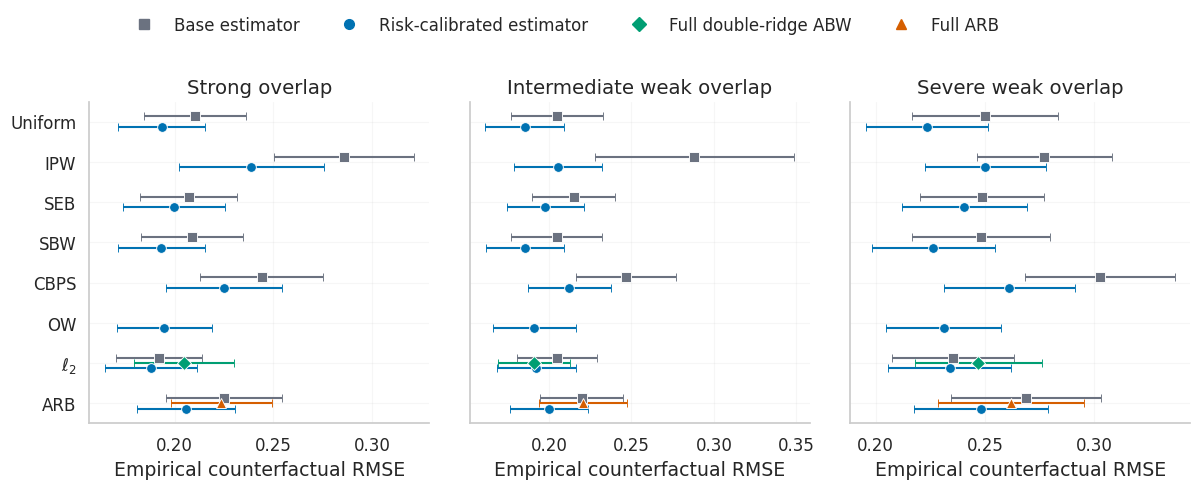

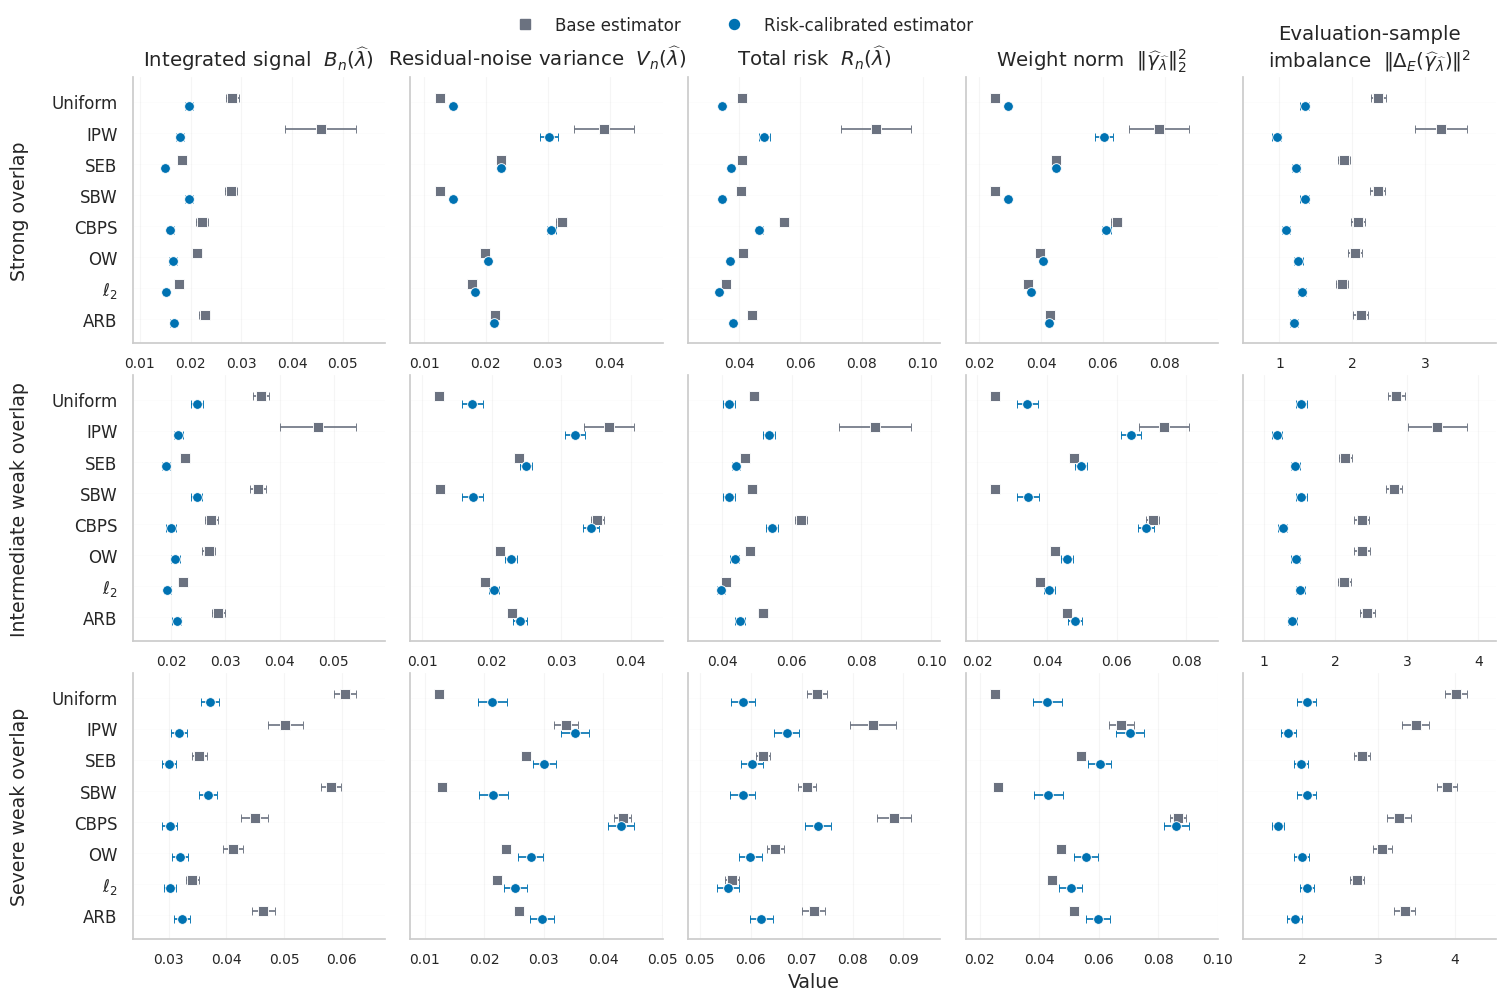

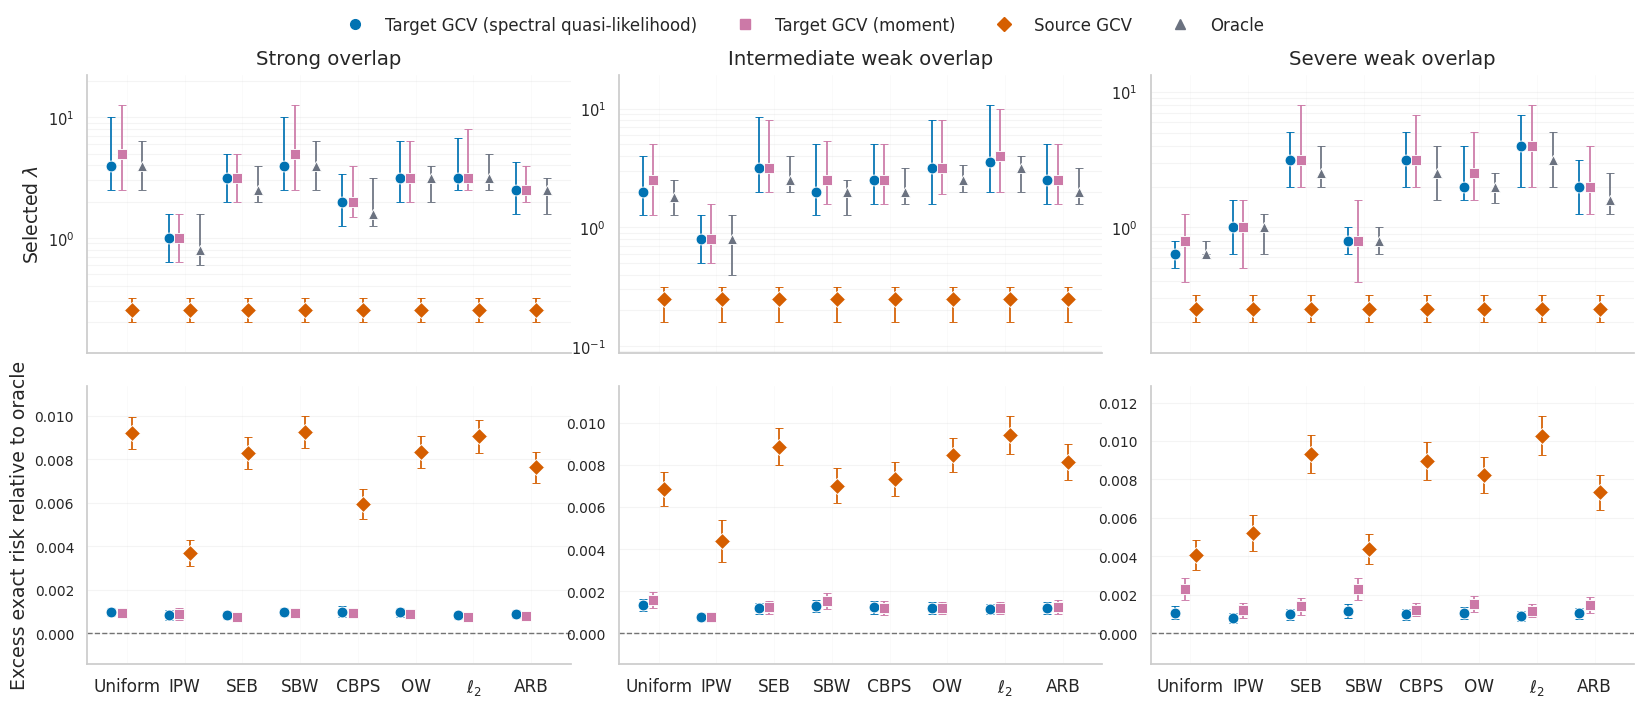

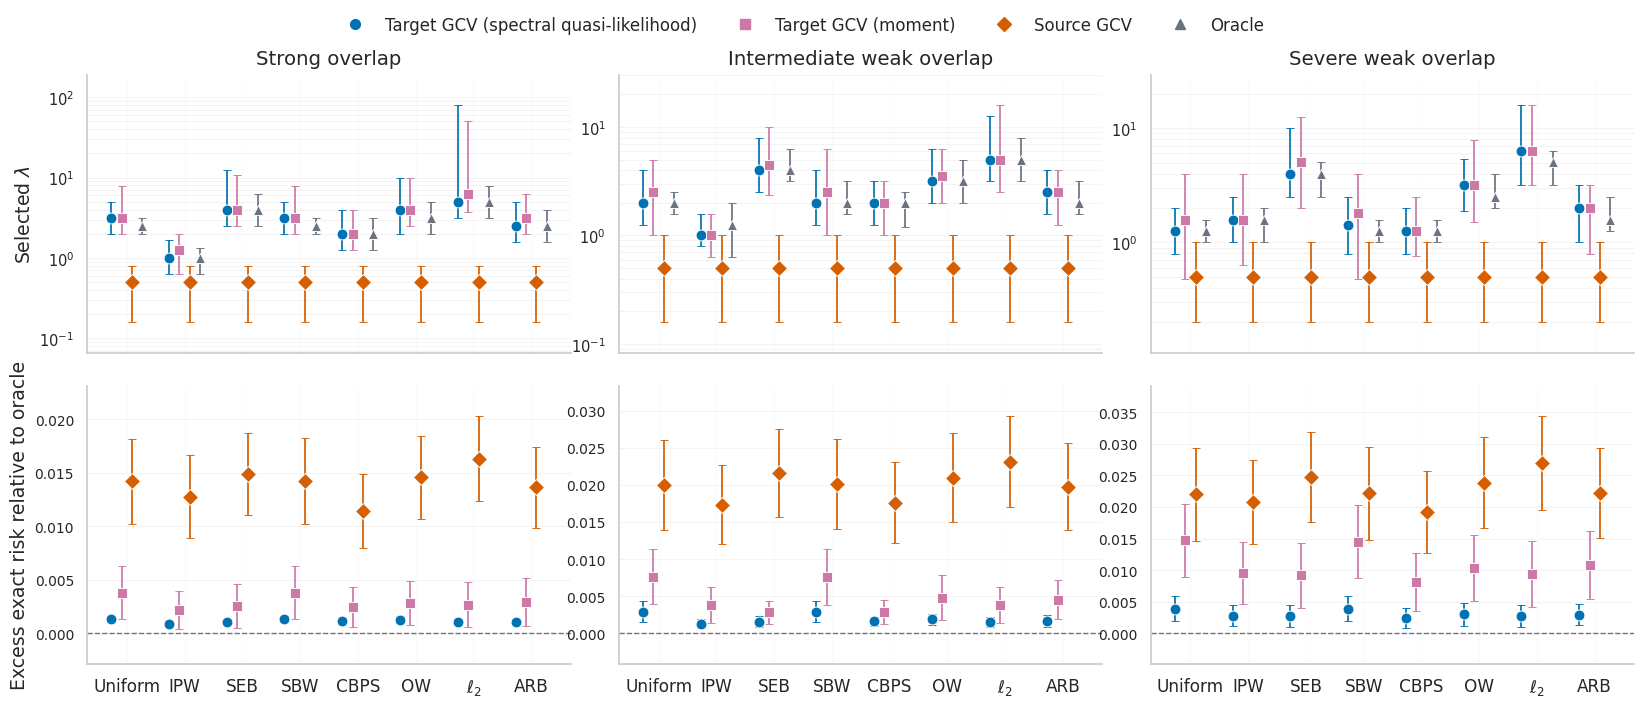

**Evaluation Figure 1.** Complete-estimator empirical RMSE.
**Evaluation Figure 2.** Exact-risk and geometry decomposition.
**Evaluation Figure 3.** Penalty selection and excess exact risk.


In [5]:
render_complete_estimator_figure()
render_metric_figures()
render_tuning_figures()

captions = {
    "00_complete_estimators": "**Evaluation Figure 1.** Complete-estimator empirical RMSE.",
    "01_required_metrics": "**Evaluation Figure 2.** Exact-risk and geometry decomposition.",
    "02_tuning_rules": "**Evaluation Figure 3.** Penalty selection and excess exact risk.",
}
for caption in captions.values():
    print(caption)

### 7. Isotropic sensitivity appendix panels

The tuning-rule comparison (Evaluation Figure 3, `phi1=0.50`) rerun under the
isotropic design `Sigma0=Sigma1=I_p`, in place of the shared AR(1) covariance. `draw_replication(..., isotropic=True)` reuses the AR(1) sweep's exact
seed coordinates, so the two sweeps share the same underlying standard-Gaussian draws and
differ only in the covariance transform applied to them (common random numbers) -- the
cleanest possible isotropic-vs-AR(1) contrast, and the same principle behind the
simulation study's isotropic control.


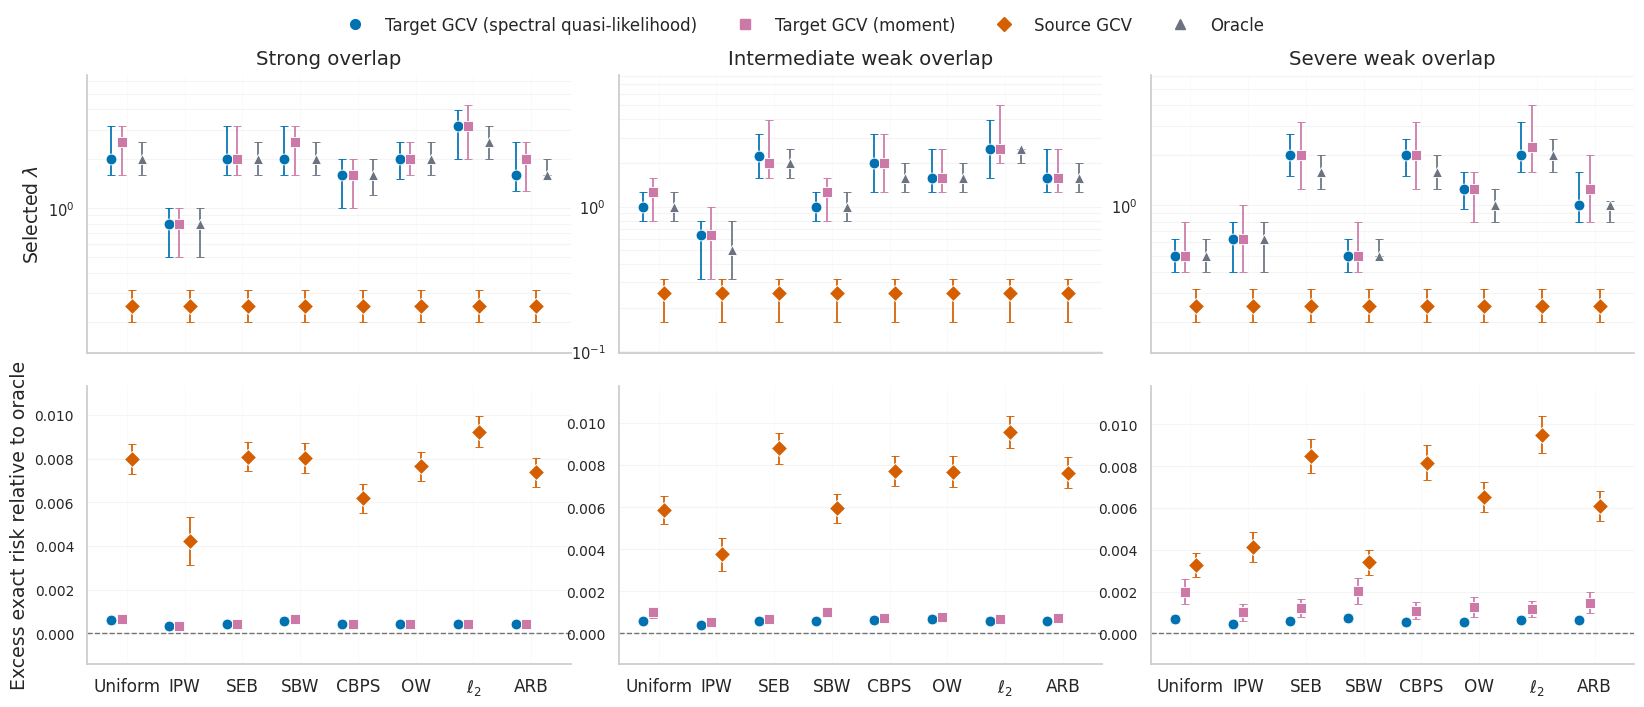

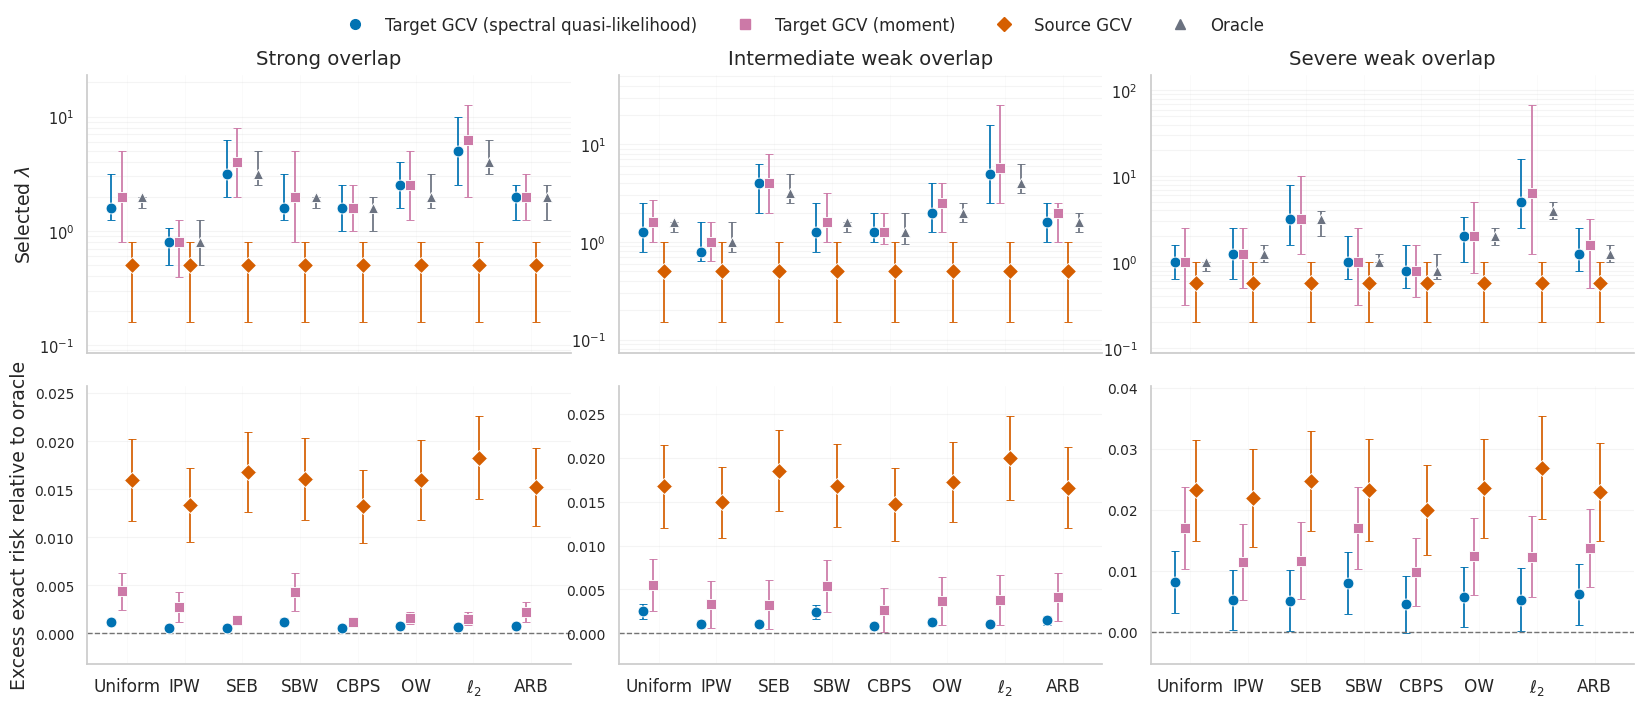

**Isotropic sensitivity appendix.** Tuning-rule comparison under Sigma0=I_p.


In [6]:
render_tuning_figures(
    penalty_path=ARTIFACT_DIR / "tuning_selection_summary_isotropic.csv",
    excess_path=ARTIFACT_DIR / "tuning_excess_exact_risk_isotropic.csv",
    specs=[
        (0.5, "05_isotropic_tuning_rules_phi0_0p5.pdf"),
        (1.25, "05_isotropic_tuning_rules_phi0_1p25.pdf"),
    ],
)
print("**Isotropic sensitivity appendix.** Tuning-rule comparison under Sigma0=I_p.")


### 8. Response-model robustness appendix panel

The overparameterized adaptive-tuning experiment rerun with the isotropic
random-effects outcome law replaced by four fixed response surfaces --
high-spectrum, low-spectrum and sparse linear, and one with a quadratic
component the working model cannot represent.  Everything else is the
experiment above: the same seeds, design, honest split, $\ell_2$ base,
penalty grid and variance-component estimator.

The metric is the *actual* counterfactual-mean prediction error
$(\widehat\gamma_{\widehat\lambda}^\top y_0-\mu_m)^2$ against the known
population target mean, reported relative to the infeasible oracle for the
fixed-surface conditional risk.  It is deliberately not the criterion
$\widehat R_n$: under a fixed surface the random-effects risk the criterion
estimates is no longer the estimand's error, so scoring the rule by its own
criterion would beg the question.


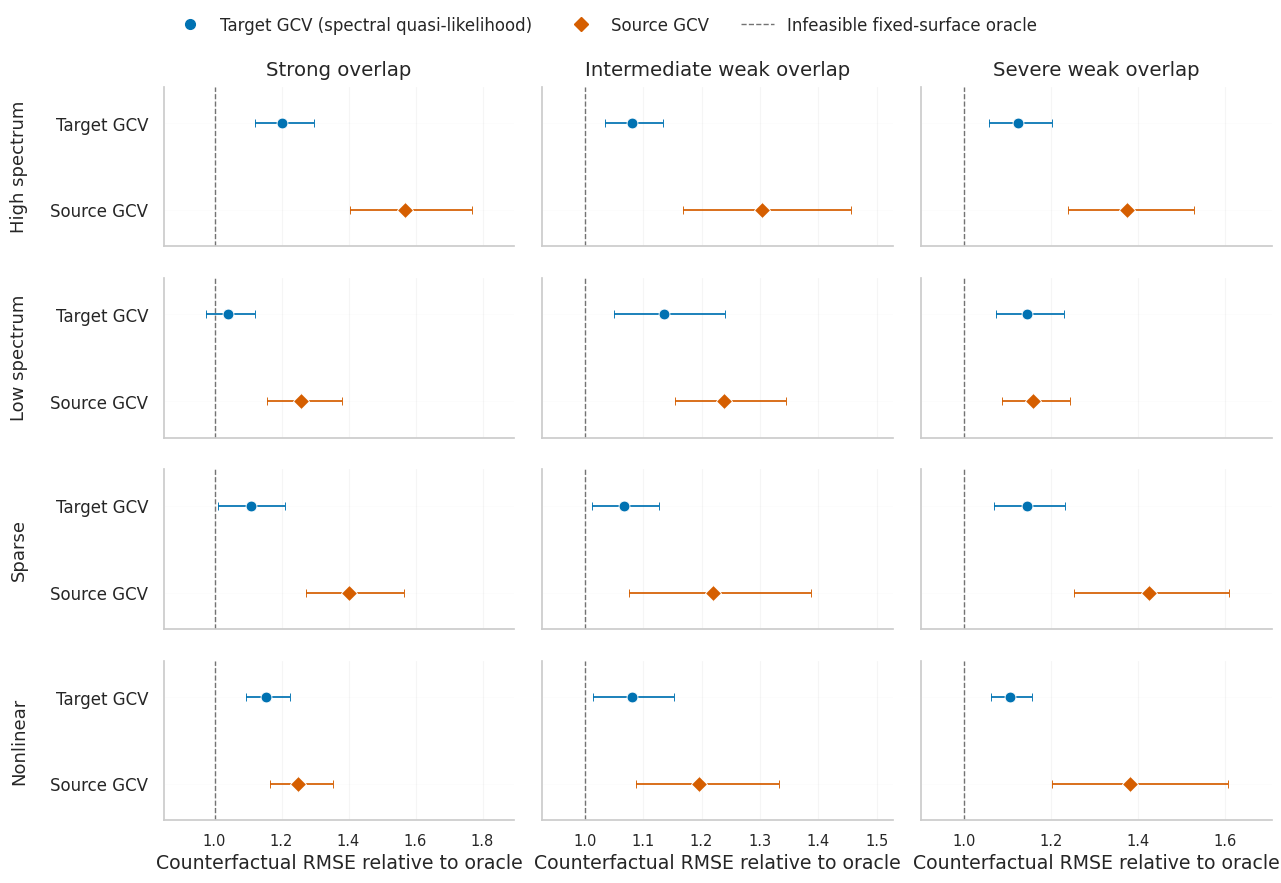

**Appendix panel.** Response-model robustness: counterfactual-mean RMSE relative to the infeasible fixed-surface oracle.


In [7]:
RESPONSE_SURFACE_LABELS = {
    "High spectrum": "High spectrum",
    "Low spectrum": "Low spectrum",
    "Sparse": "Sparse",
    "Nonlinear": "Nonlinear",
}
RESPONSE_RULE_COLORS = {
    "Spectral target-aware": PALETTE["blue"], "Source GCV": PALETTE["vermillion"],
}
RESPONSE_RULE_MARKERS = {"Spectral target-aware": "o", "Source GCV": "D"}


def render_response_robustness_figure(
    summary: pd.DataFrame | None = None,
    *,
    summary_path: Path | None = None,
    canonical: str = "06_response_robustness.pdf",
) -> None:
    """Appendix E's response-model robustness panel.

    Rows are the four fixed response surfaces and columns the three overlap
    regimes.  Each point is the counterfactual-mean RMSE ratio to the
    infeasible fixed-surface oracle, whose value is one by construction and is
    drawn as the dashed reference line; the bars are paired Monte Carlo
    bootstrap intervals over the 120 common replications.
    """
    if summary is None:
        summary = pd.read_csv(
            summary_path or (ARTIFACT_DIR / "response_robustness_summary.csv")
        )
    rules = list(RESPONSE_RULE_COLORS)
    surfaces = list(RESPONSE_SURFACE_LABELS)
    y = np.arange(len(rules))[::-1].astype(float)
    fig, axes = plt.subplots(
        len(surfaces), len(OVERLAPS), figsize=(13.6, 9.0),
        sharex="col", sharey=True, squeeze=False,
    )
    for row, surface in enumerate(surfaces):
        for col, overlap in enumerate(OVERLAPS):
            ax = axes[row, col]
            panel = summary[
                summary["surface"].eq(surface) & summary["overlap"].eq(overlap)
            ].set_index("rule")
            ax.axvline(1.0, color=".45", linewidth=1.0, linestyle="--", zorder=1)
            for position, rule in zip(y, rules):
                values = panel.loc[rule]
                center = float(values["rmse_ratio_to_oracle"])
                ax.errorbar(
                    center, position,
                    xerr=np.array([[center - float(values["rmse_ratio_lower_95"])],
                                   [float(values["rmse_ratio_upper_95"]) - center]]),
                    color=RESPONSE_RULE_COLORS[rule],
                    marker=RESPONSE_RULE_MARKERS[rule], linestyle="none",
                    markersize=7.8, capsize=3.0, elinewidth=1.25,
                    markeredgecolor="white", markeredgewidth=.65, zorder=3,
                )
            if row == 0:
                ax.set_title(overlap, pad=8)
            if col == 0:
                ax.set_ylabel(RESPONSE_SURFACE_LABELS[surface], labelpad=16,
                              fontsize=13.0)
            if row == len(surfaces) - 1:
                ax.set_xlabel("Counterfactual RMSE relative to oracle")
            ax.set_yticks(y)
            ax.set_yticklabels(["Target GCV", "Source GCV"])
            ax.tick_params(axis="y", labelleft=(col == 0), pad=5)
            ax.tick_params(axis="x", labelsize=10.5)
            ax.grid(axis="x", alpha=.19); ax.grid(axis="y", alpha=.06)
            ax.margins(x=.16, y=.42)
    handles = [
        Line2D([0], [0], color=RESPONSE_RULE_COLORS[rule],
               marker=RESPONSE_RULE_MARKERS[rule], linestyle="none",
               markersize=7.0, label=label)
        for rule, label in zip(
            rules, ["Target GCV (spectral quasi-likelihood)", "Source GCV"]
        )
    ] + [Line2D([0], [0], color=".45", linestyle="--", linewidth=1.0,
                label="Infeasible fixed-surface oracle")]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(.5, .995),
               ncol=3, frameon=False, columnspacing=1.9)
    fig.subplots_adjust(left=.175, right=.99, bottom=.085, top=.9,
                        hspace=.2, wspace=.08)
    _save(fig, canonical)


render_response_robustness_figure()
print(
    "**Appendix panel.** Response-model robustness: counterfactual-mean RMSE "
    "relative to the infeasible fixed-surface oracle."
)
